# Paso 05 -- Comparar el agente PPO contra la politica base

Corre el agente entrenado (`output/rl_ppo/modelo_ppo.zip`, paso 04) y la
politica base (`asignar_flota`) sobre las MISMAS semillas de evaluacion
(`agente.evaluacion.semillas` en el config -- distintas de
`semilla_entrenamiento`, para no evaluar sobre demandas ya vistas), en la
misma instancia de entrenamiento (escalon chico). Misma semilla -> misma
demanda para las dos politicas (ver `entrenamiento.py`), asi la comparacion
es justa.

**Como se agregan los resultados:** igual que el escalon 3 (semana) -- cada
semilla de evaluacion es su propio episodio independiente;
`metricas.combinar_corridas` junta los N episodios de cada politica en un
solo objeto y `metricas.reporte_completo` da las mismas tablas de siempre,
ahora una por politica, listas para comparar lado a lado. Cero funciones de
metricas nuevas.

**Objetivo de esta primera version:** mostrar si el agente iguala o supera
a la politica base -- no se exige que gane.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
BB_DIR = (BASE_DIR / "../bergen-boats").resolve()
DEMAND_DIR = (BASE_DIR / "../demand").resolve()
sys.path.insert(0, str(DEMAND_DIR / "src"))
sys.path.insert(0, str(BASE_DIR / "src"))

import masas as demand_masas
import llegadas as demand_llegadas
from entrenamiento import EntornoDemandaAleatoria
from politica_base import asignar_flota
import metricas as met
import visualizacion as viz
from stable_baselines3 import PPO

cfg_sim = yaml.safe_load(open(BASE_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_bb = yaml.safe_load(open(BB_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_demand = demand_masas.cargar_config(DEMAND_DIR / "config" / "instance.yaml")

resumen_masas = pd.read_csv(DEMAND_DIR / "output" / "masas_por_nodo.csv", index_col="id")
intensidad_od = pd.read_csv(DEMAND_DIR / "output" / "matriz_intensidad_od.csv")
poblacion_total_zonas = resumen_masas["poblacion_total"].sum()
conexiones_fuertes = cfg_bb["garantia"]["conexiones_fuertes"]

nodos = [n["id"] for n in cfg_bb["nodos_demanda"]]
matriz_tiempos = pd.read_csv(BB_DIR / "02_ruteo_navegable" / "output" / "matriz_tiempos_min.csv", index_col=0)

cfg_agente = cfg_sim["agente"]
cfg_entren = cfg_agente["entrenamiento"]
cfg_escalon = cfg_sim["escalones"][cfg_entren["escalon_base"]]
hora_ini_min, hora_fin_min = cfg_escalon["horas"][0] * 60, cfg_escalon["horas"][1] * 60
semillas_eval = cfg_agente["evaluacion"]["semillas"]

RL_DIR = BASE_DIR / "output" / "rl_ppo"
OUT_DIR = BASE_DIR / "output" / "comparacion"
OUT_DIR.mkdir(parents=True, exist_ok=True)

model = PPO.load(str(RL_DIR / "modelo_ppo"))
print("Modelo cargado de", RL_DIR / "modelo_ppo.zip")
print(f"Instancia de evaluacion: {cfg_entren['escalon_base']}, semillas: {semillas_eval}")


def construir_entorno_eval():
    return EntornoDemandaAleatoria(
        generar_llegadas_dia_fn=demand_llegadas.generar_llegadas_dia,
        cfg_demand=cfg_demand, intensidad_od=intensidad_od, conexiones_fuertes=conexiones_fuertes,
        poblacion_total_zonas=poblacion_total_zonas, horas=cfg_escalon["horas"],
        porcentaje_poblacion_dia=cfg_escalon["porcentaje_poblacion_dia"],
        matriz_tiempos=matriz_tiempos, nodos=nodos, num_barcos=cfg_escalon["num_barcos"],
        capacidad_barco=cfg_bb["flota"]["capacidad_pasajeros"], nodo_inicial=cfg_bb["flota"]["nodo_inicial"],
        paso_tiempo_min=cfg_sim["paso_tiempo_min"], hora_inicio_min=hora_ini_min, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_sim["recompensa"], unidad_demanda=cfg_sim["unidad_demanda"],
    )


Modelo cargado de C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\simulacion\output\rl_ppo\modelo_ppo.zip
Instancia de evaluacion: escalon_1, semillas: [1001, 1002, 1003, 1004, 1005]


## Correr las dos politicas sobre las mismas semillas de evaluacion

In [2]:
def correr_agente(semilla):
    env = construir_entorno_eval()
    obs, info = env.reset(seed=semilla)
    reward_total = 0.0
    while True:
        accion, _ = model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, info = env.step(accion)
        reward_total += r
        if truncated or terminated:
            break
    return env, reward_total


def correr_base(semilla):
    env = construir_entorno_eval()
    obs, info = env.reset(seed=semilla)
    reward_total = 0.0
    while True:
        estado = info["_estado_obj"]
        libres = [b for b in estado.barcos if b.libre]
        decisiones = asignar_flota(libres, estado, matriz_tiempos, env.capacidad_barco, cfg_sim["recompensa"])
        accion = np.array([
            env.codificar_accion_barco(decisiones[b.id]) if b.libre else 0
            for b in estado.barcos
        ])
        obs, r, terminated, truncated, info = env.step(accion)
        reward_total += r
        if truncated or terminated:
            break
    return env, reward_total


envs_agente, envs_base = [], []
filas_reward = []
for semilla in semillas_eval:
    env_a, r_a = correr_agente(semilla)
    env_b, r_b = correr_base(semilla)
    envs_agente.append(env_a)
    envs_base.append(env_b)
    filas_reward.append({"semilla": semilla, "reward_agente": r_a, "reward_base": r_b, "diferencia": r_a - r_b})
    print(f"semilla {semilla}: agente={r_a:8.2f}  base={r_b:8.2f}  diferencia={r_a - r_b:+8.2f}")

df_reward = pd.DataFrame(filas_reward)
df_reward.to_csv(OUT_DIR / "reward_por_semilla.csv", index=False)
print(f"\nPromedio: agente={df_reward['reward_agente'].mean():.2f}  base={df_reward['reward_base'].mean():.2f}")


semilla 1001: agente=-2364.59  base= -127.90  diferencia=-2236.69
semilla 1002: agente=-2891.41  base= -448.96  diferencia=-2442.46


semilla 1003: agente=-5196.24  base= -274.83  diferencia=-4921.42


semilla 1004: agente=-3752.75  base=-1481.33  diferencia=-2271.42
semilla 1005: agente=-3708.76  base= -111.45  diferencia=-3597.30

Promedio: agente=-3582.75  base=-488.89


## Combinar las 5 corridas de cada politica y sacar las metricas de siempre

Mismo mecanismo que el escalon 3 (`metricas.combinar_corridas` +
`metricas.reporte_completo`) -- aca cada "dia" es una semilla de
evaluacion distinta, en vez de un dia de la semana.

In [3]:
corrida_agente = met.combinar_corridas(envs_agente)
corrida_base = met.combinar_corridas(envs_base)

reporte_agente = met.reporte_completo(corrida_agente)
reporte_base = met.reporte_completo(corrida_base)

print("Conservacion agente:", reporte_agente["conservacion"]["cuadra"])
print("Conservacion base:  ", reporte_base["conservacion"]["cuadra"])


Conservacion agente: True
Conservacion base:   True


## Tabla comparativa (globales)

In [4]:
claves_comparar = [
    "unidades_generadas", "unidades_atendidas", "unidades_sin_atender_al_final",
    "pct_atendidas", "espera_media_min", "sistema_medio_min", "sistema_maximo_min",
]
tabla_comparativa = pd.DataFrame({
    "metrica": claves_comparar,
    "agente_ppo": [reporte_agente["globales"][k] for k in claves_comparar],
    "politica_base": [reporte_base["globales"][k] for k in claves_comparar],
})
tabla_comparativa["diferencia"] = tabla_comparativa["agente_ppo"] - tabla_comparativa["politica_base"]

# Recompensa total y movimientos/ocupacion de flota, tambien comparados
tabla_comparativa = pd.concat([tabla_comparativa, pd.DataFrame([
    {"metrica": "reward_total", "agente_ppo": df_reward["reward_agente"].sum(),
     "politica_base": df_reward["reward_base"].sum(),
     "diferencia": df_reward["reward_agente"].sum() - df_reward["reward_base"].sum()},
    {"metrica": "movimientos_totales", "agente_ppo": reporte_agente["por_barco"]["movimientos"].sum(),
     "politica_base": reporte_base["por_barco"]["movimientos"].sum(),
     "diferencia": reporte_agente["por_barco"]["movimientos"].sum() - reporte_base["por_barco"]["movimientos"].sum()},
    {"metrica": "ocupacion_media", "agente_ppo": reporte_agente["por_barco"]["ocupacion_media"].mean(),
     "politica_base": reporte_base["por_barco"]["ocupacion_media"].mean(),
     "diferencia": reporte_agente["por_barco"]["ocupacion_media"].mean() - reporte_base["por_barco"]["ocupacion_media"].mean()},
])], ignore_index=True)

tabla_comparativa.to_csv(OUT_DIR / "tabla_comparativa.csv", index=False)
display(tabla_comparativa.round(2))


,metrica,agente_ppo,politica_base,diferencia
0,unidades_generadas,850.00,850.00,0.00
1,unidades_atendidas,235.00,748.00,-513.00
2,unidades_sin_atender_al_final,615.00,102.00,513.00
3,pct_atendidas,27.65,88.00,-60.35
4,espera_media_min,10.49,16.42,-5.93
5,sistema_medio_min,21.21,26.05,-4.84
6,sistema_maximo_min,36.25,69.74,-33.49
7,reward_total,-17913.76,-2444.46,-15469.29
8,movimientos_totales,79.00,155.00,-76.00
9,ocupacion_media,1.15,3.50,-2.35


## Comparacion por par origen-destino

In [5]:
par_agente = reporte_agente["por_par"][["par", "pct_atendidas", "espera_media_min", "sistema_medio_min"]]
par_base = reporte_base["por_par"][["par", "pct_atendidas", "espera_media_min", "sistema_medio_min"]]
por_par_comparado = par_agente.merge(par_base, on="par", suffixes=("_agente", "_base"))
por_par_comparado.to_csv(OUT_DIR / "por_par_comparado.csv", index=False)
display(por_par_comparado.round(1))


,par,pct_atendidas_agente,espera_media_min_agente,sistema_medio_min_agente,pct_atendidas_base,espera_media_min_base,sistema_medio_min_base
0,kleppesto->laksevag,0.0,NaN,NaN,100.0,7.7,13.7
1,kleppesto->bryggen,32.6,12.2,24.3,80.8,17.0,24.9
2,kleppesto->sandviken,0.0,NaN,NaN,100.0,15.6,23.3
3,laksevag->kleppesto,0.0,NaN,NaN,100.0,25.3,58.8
4,laksevag->bryggen,60.2,9.4,20.0,85.7,23.1,28.3
5,laksevag->sandviken,0.0,NaN,NaN,60.0,27.1,37.1
6,bryggen->kleppesto,0.0,NaN,NaN,100.0,17.2,23.9
7,bryggen->laksevag,75.0,7.4,17.4,100.0,7.2,23.1
8,bryggen->sandviken,0.0,NaN,NaN,100.0,11.1,22.7
9,sandviken->kleppesto,0.0,NaN,NaN,100.0,16.2,26.2


## Graficas comparativas

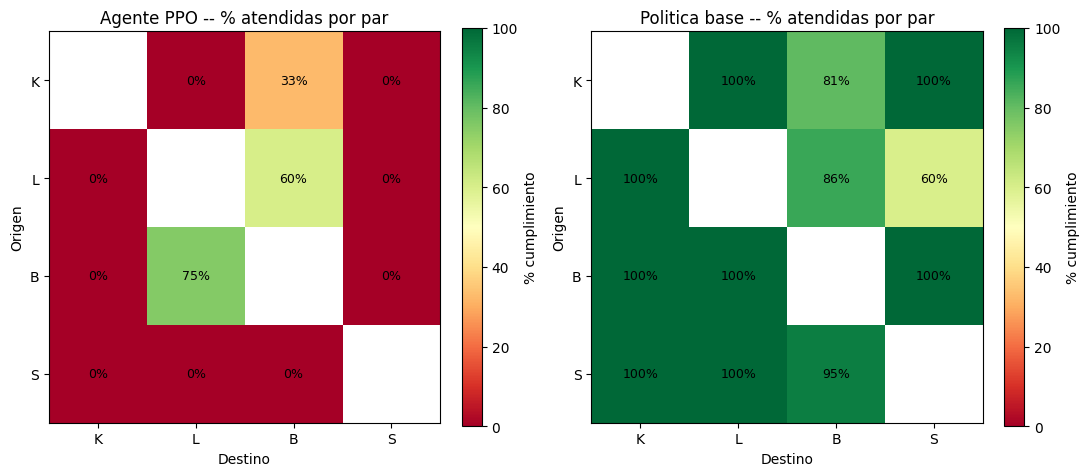

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
viz.graficar_heatmap_cumplimiento(corrida_agente, ax=axs[0])
axs[0].set_title("Agente PPO -- % atendidas por par")
viz.graficar_heatmap_cumplimiento(corrida_base, ax=axs[1])
axs[1].set_title("Politica base -- % atendidas por par")
fig.tight_layout()
fig.savefig(OUT_DIR / "heatmaps_comparados.png", dpi=150)
plt.show()


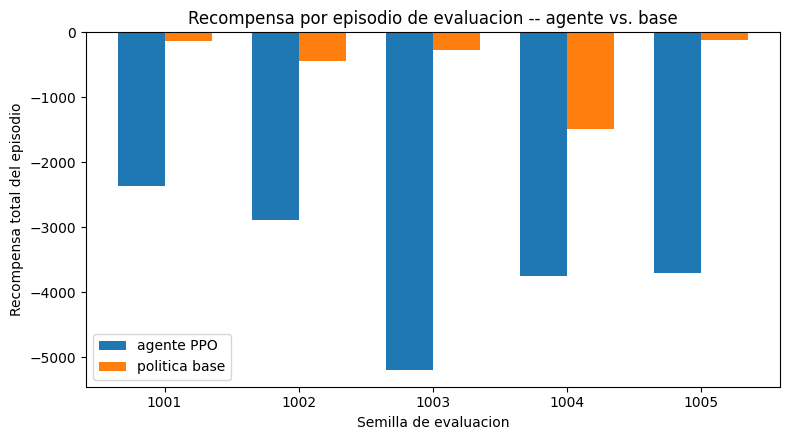

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(semillas_eval))
ancho = 0.35
ax.bar(x - ancho / 2, df_reward["reward_agente"], ancho, label="agente PPO")
ax.bar(x + ancho / 2, df_reward["reward_base"], ancho, label="politica base")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in semillas_eval])
ax.set_xlabel("Semilla de evaluacion")
ax.set_ylabel("Recompensa total del episodio")
ax.set_title("Recompensa por episodio de evaluacion -- agente vs. base")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "reward_por_semilla.png", dpi=150)
plt.show()
